In [77]:
using PyPlot
using JLD2
using Statistics
using ProgressBars
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [78]:
# pathdir = "Y:/TwoDGas/2025/07/04" # Old dataset
# pathdir = "Y:/TwoDGas/2026/01/19/0046" # New dataset
pathdir = "Y:/StructuralPhaseTransition/2026/02/02/0000" # Tilted 15°
@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/Droplets_"*join(split(pathdir, "/")[3:end], "_")*".jld2" centers_droplets_ds nbr_droplets_ds
# size_pxl = 0.187e-6;
size_pxl = 0.1966e-6; # New pxl size since 2025/12/31


### Check validity of image region

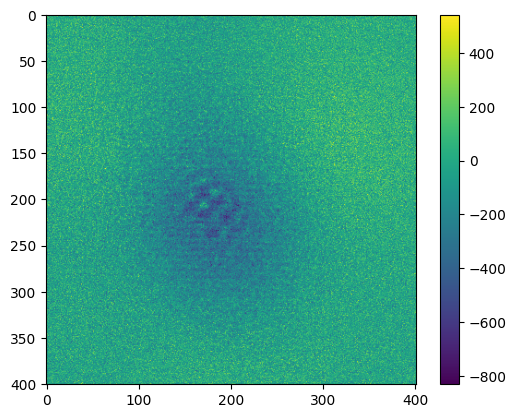

In [79]:
i, j = 4, 1

close("all")
fig, axs = subplots()

# img1 = imshow(Imgs_atoms_crop_ds[i, j, :, :])
img1 = imshow(Imgs_atoms_crop_ds[i, j, :, :]-Imgs_bkg_crop_ds[i, j, :, :])
colorbar(img1)

# pygui(true); show()
pygui(false);

### Intensity integrated over the condensate

In [87]:
Iatoms_img, Ibkg_img, Idark_img = zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2])

if length(τ_exp) == 1
    Convertion_factor = 0.107 / (0.85 * τ_exp)
end

for i = ProgressBar(1:length(Sat))
    if length(τ_exp) > 1
        Convertion_factor = 0.107 / (0.85 * τ_exp[i])
    end

    for j = 1:size(Imgs_atoms_crop_ds)[2]
        Iatoms_img[i, j] = sum(Imgs_atoms_crop_ds[i, j, :, :])
        Ibkg_img[i, j] = sum(Imgs_bkg_crop_ds[i, j, :, :])
        Idark_img[i, j] = sum(Imgs_dark_crop_ds[i, j, :, :])
        
        Iatoms_img[i, j] *= Convertion_factor
        Ibkg_img[i, j] *= Convertion_factor
        Idark_img[i, j] *= Convertion_factor
    end
end

# Convert to W/m^2
S_img = size(Imgs_atoms_crop_ds)[3]*size(Imgs_atoms_crop_ds)[4]*size_pxl^2
Iatoms_img /= S_img
Ibkg_img /= S_img
Idark_img /= S_img;

0.0%┣                                               ┫ 0/19 [00:00<00:00, -0s/it]
5.3%┣██▎                                        ┫ 1/19 [00:00<Inf:Inf, InfGs/it]
10.5%┣█████                                          ┫ 2/19 [00:00<00:08, 2it/s]
15.8%┣███████▍                                       ┫ 3/19 [00:01<00:05, 3it/s]
21.1%┣██████████                                     ┫ 4/19 [00:01<00:04, 4it/s]
26.3%┣████████████▍                                  ┫ 5/19 [00:01<00:04, 4it/s]
31.6%┣██████████████▉                                ┫ 6/19 [00:01<00:03, 4it/s]
36.8%┣█████████████████▎                             ┫ 7/19 [00:01<00:03, 4it/s]
42.1%┣███████████████████▉                           ┫ 8/19 [00:02<00:02, 4it/s]
47.4%┣██████████████████████▎                        ┫ 9/19 [00:02<00:02, 5it/s]
52.6%┣████████████████████████▏                     ┫ 10/19 [00:02<00:02, 5it/s]
57.9%┣██████████████████████████▋                   ┫ 11/19 [00:02<00:02, 5it/s]
63.2%┣██████████████████████

### Compute mean/std

In [88]:
Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms = zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat))
Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms = zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat))

for i = 1:size(Imgs_atoms_crop_ds)[1]
    atoms, bkg, dark, bkg_atoms = [], [], [], []
    for j = 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_droplets_ds[i, j] > 0
            push!(atoms, Iatoms_img[i, j]), push!(bkg, Ibkg_img[i, j]), push!(dark, Idark_img[i, j]), push!(bkg_atoms, Ibkg_img[i, j]-Iatoms_img[i, j])
        end
        
    end

    if length(atoms[atoms.>0]) > 0
        Mean_atoms[i], Mean_bkg[i], Mean_dark[i], Mean_bkg_atoms[i] = mean(atoms), mean(bkg), mean(dark), mean(bkg_atoms)
        Std_atoms[i], Std_bkg[i], Std_dark[i], Std_bkg_atoms[i] = std(atoms), std(bkg), std(dark), std(bkg_atoms)
    end
end

### Plots

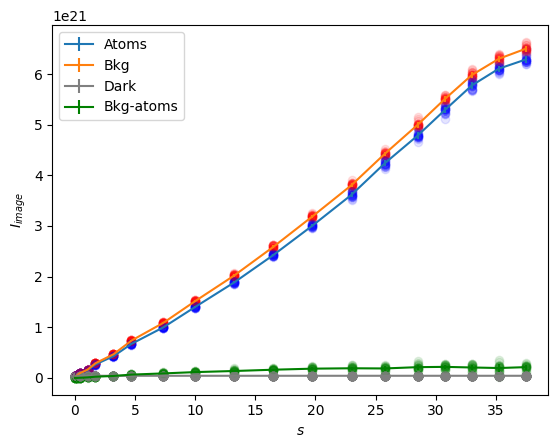

In [82]:
close("all")
fig = subplots()

errorbar(Sat, Mean_atoms, yerr=Std_atoms, label="Atoms")
errorbar(Sat, Mean_bkg, yerr=Std_bkg, label="Bkg")
errorbar(Sat, Mean_dark, yerr=Std_dark, label="Dark", color="grey")
errorbar(Sat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="g")


for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Iatoms_img[i, j], color="b", alpha = 0.1)
        scatter(Sat[i], Ibkg_img[i, j], color="r", alpha = 0.1)
        scatter(Sat[i], Idark_img[i, j], color="grey")
        scatter(Sat[i], Ibkg_img[i, j]-Iatoms_img[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{image}")

legend()

# pygui(true); show();
pygui(false);

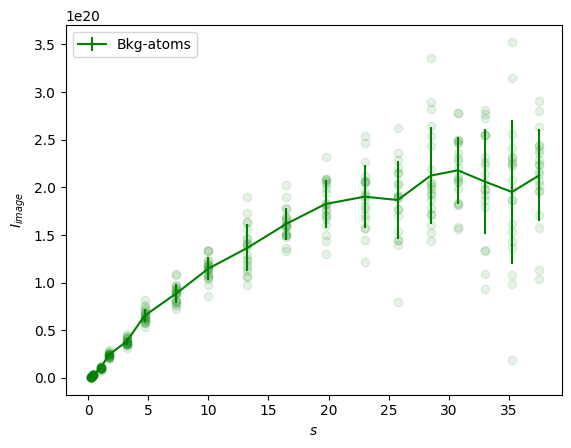

In [83]:
close("all")
fig = subplots()

errorbar(Sat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="g")

for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_droplets_ds[i, j] > 0
            scatter(Sat[i], Ibkg_img[i, j]-Iatoms_img[i, j], color="g", alpha = 0.1)
        end
    end
end

xlabel(L"s")
ylabel(L"I_{image}")

legend()

# pygui(true); show();
pygui(false);

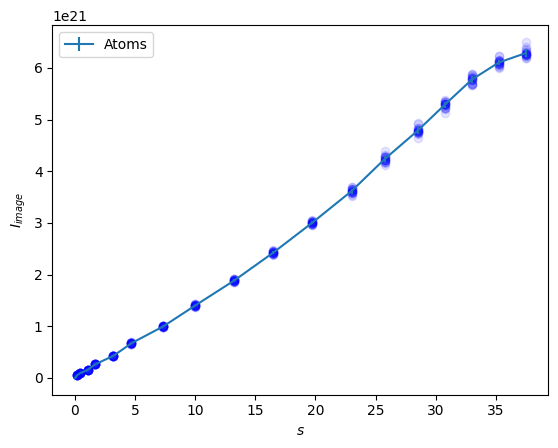

In [84]:
close("all")
fig = subplots()

errorbar(Sat, Mean_atoms, yerr=Std_atoms, label="Atoms")


for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_droplets_ds[i, j] > 0
            scatter(Sat[i], Iatoms_img[i, j], color="b", alpha = 0.1)
        end
    end
end

xlabel(L"s")
ylabel(L"I_{image}")

legend()

# pygui(true); show();
pygui(false);

In [85]:
@save "Saved_exp_data/Intensity_integrated_all_img_droplets_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat Iatoms_img Ibkg_img Idark_img Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms;

### Plot as a function of computed Sat

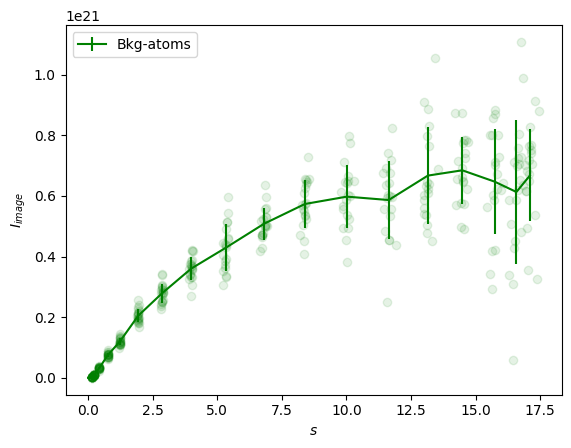

In [89]:
Γ = 2.02e8 # In Hz
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ
Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2)

close("all")
fig = subplots()

errorbar(Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="g")

for i in 1:size(Imgs_atoms_crop_ds)[1]
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_droplets_ds[i, j] > 0
            scatter(Ibkg_img[i, j]/Isat, Ibkg_img[i, j]-Iatoms_img[i, j], color="g", alpha = 0.1)
        end
    end
end

xlabel(L"s")
ylabel(L"I_{image}")

legend()

# pygui(true); show();
pygui(false);